In [1]:
from stpy.kernels import KernelFunction
from stpy.continuous_processes.nystrom_fea import NystromFeatures
from stpy.helpers.helper import interval_torch
import torch
from torch.nn import Sequential, Linear
import torch.optim as optim

2024-10-30 10:15:38.384626: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-10-30 10:15:38.420694: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-10-30 10:15:38.898726: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
# General convention
# x \in (n,d)
# y \in (n,1)

In [3]:
kernel = KernelFunction(kernel_name="matern", gamma=0.1, nu = 3.5, d = 1)

In [4]:
# custom kernel
kernel_fn = lambda x,y: torch.sum(x**2 + y**2).view(-1,1)
kernel_custom = KernelFunction(kernel_function=kernel_fn, d = 1)

In [5]:
x = interval_torch(10,1)

In [6]:
# creation of embedding object with m basis functions
embedding = NystromFeatures(kernel, m=10, approx="svd")
embedding.fit_gp(x,None)

In [7]:
#phi = lambda x: embedding.embed(x)

In [8]:
class ShallowModel(Sequential):
    def __init__(self, input_dim, output_dim, embedding):
        super(ShallowModel, self).__init__()
        self.dense = Linear(embedding.get_m(), output_dim, bias=False).double()
        self.phi = lambda x: embedding.embed(x)

    def forward(self, input):
        return self.dense(self.phi(input))

model = ShallowModel(1,1, embedding)

In [21]:
optimizer = optim.Adam(model.parameters(), lr=0.01)

x = interval_torch(10,1).double()
test_fn = lambda x: torch.sin(x*20)
y = test_fn(x)

def loss_fn(x,y,model):
    y_hat = model(x)
    # likelihood + prior
    return torch.mean((y_hat - y)**2) + 0.001*torch.sum(model.dense.weight**2)

for i in range(1000):
    optimizer.zero_grad()
    loss = loss_fn(x,y,model)
    loss.backward()
    optimizer.step()
    print(i, loss.item())

0 0.00903487204498308
1 0.008530751645306082
2 0.008116041706413148
3 0.007772146741713287
4 0.007436884395726618
5 0.0071684960617406385
6 0.006924895660684501
7 0.006696997903553889
8 0.006492727814262005
9 0.00631317223510206
10 0.006149381335041485
11 0.005998155570229438
12 0.005865142296094113
13 0.0057537998824194105
14 0.005659573765043838
15 0.005576447117052422
16 0.005504895485383408
17 0.005448674126178762
18 0.005408738438813203
19 0.005382315824511848
20 0.005366115481341579
21 0.005358706314051882
22 0.005359516930094978
23 0.00536652648549318
24 0.005375787287511314
25 0.005384147984487651
26 0.005391422069990376
27 0.005398750982227094
28 0.005405988764476185
29 0.005411917978378745
30 0.00541622638558402
31 0.0054197428400109895
32 0.0054229505656158365
33 0.005425150548328186
34 0.005425191585852574
35 0.005422777240875707
36 0.005418711875526659
37 0.005413793942177954
38 0.005408029784516423
39 0.005401304263485856
40 0.005394113222353104
41 0.00538711201989572
42 

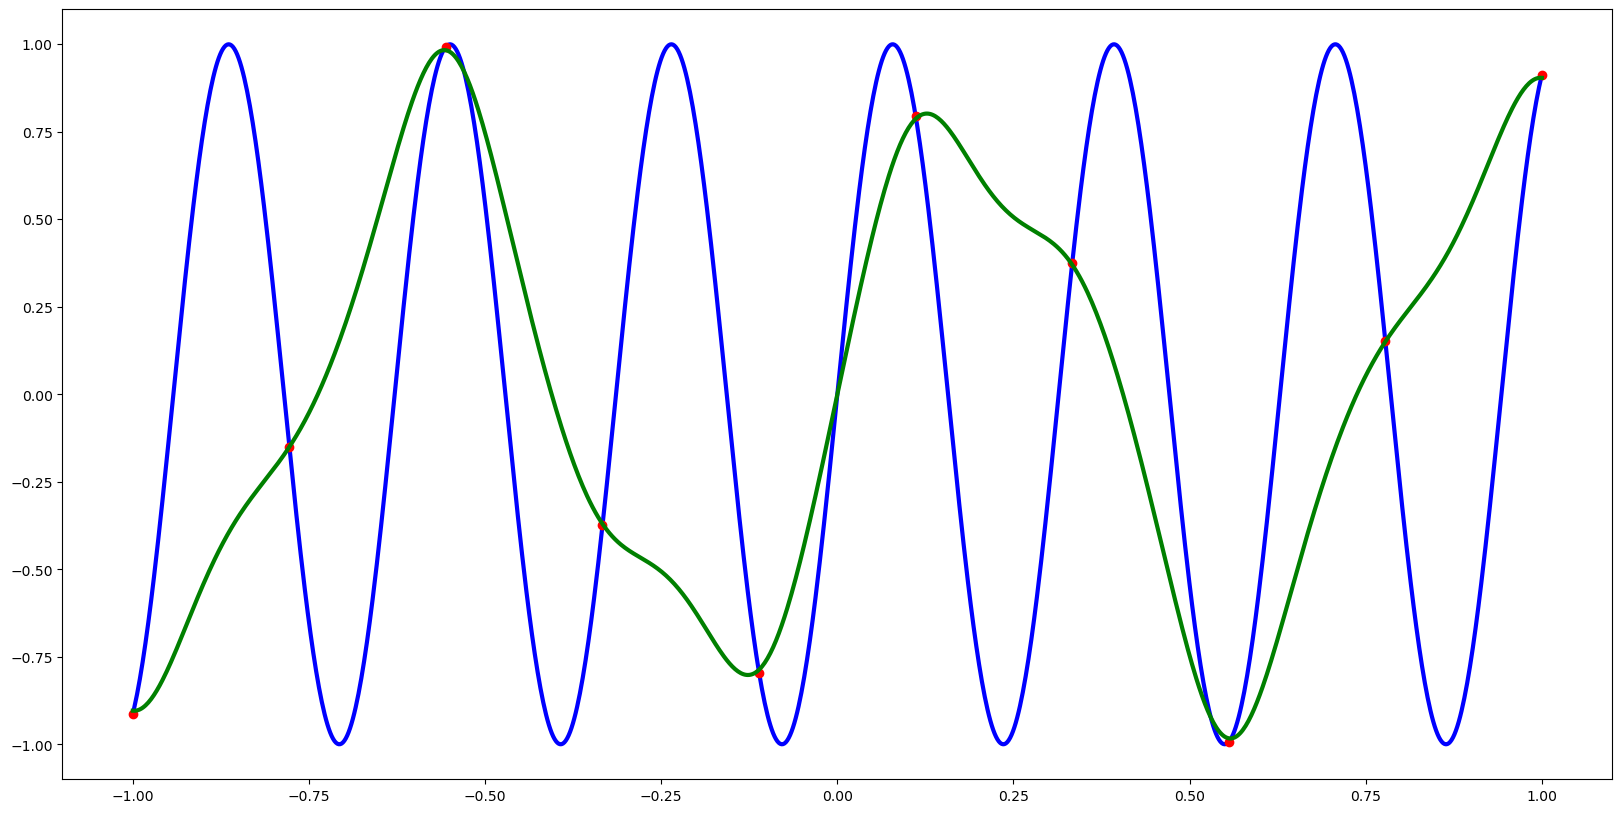

In [22]:
import matplotlib.pyplot as plt
x_fine = interval_torch(1000,1)
plt.figure(figsize=(20,10))
plt.plot(x_fine,test_fn(x_fine),'b-', lw = 3)
plt.plot(x, test_fn(x), 'ro', lw = 3)
plt.plot(x_fine, model(x_fine).detach().numpy(),'g-', lw = 3)

In [23]:
# model parameters
list(model.parameters())

[Parameter containing:
 tensor([[-1.2125e-01,  1.2857e-09,  5.6465e-01,  3.6042e-16, -2.1961e+00,
          -8.1408e-16, -3.5318e-01,  1.5458e-15,  1.2525e-01, -2.6928e-15]],
        dtype=torch.float64, requires_grad=True)]

In [24]:
# optimization of hyperparameters

In [25]:
gamma = torch.tensor(0.1, requires_grad=True)